# EEG Trigger Press · LightGBM + Feature-Space NoGo Subtraction (gng2)
## Focused Analysis with Rich Visualizations

Best pipeline from `eeg_pipeline_v2`: **LightGBM on temporal + frequency features**,
LOTO cross-validation, AP-optimised threshold.

**Visualizations**
1. Per-trial probability timeline — model score vs true horizon labels across each full trial
2. Event-related probability — average score trace locked to each press event (ERP-style)
3. Press event zoom gallery — individual 3 s windows around each detected press
4. Per-fold AUC / AP / EvtSens bar chart
5. ROC & Precision-Recall curves
6. Feature importance (mean across LOTO folds)


## 1 · Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from mne.filter import filter_data
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy.signal import welch
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

DARK, CARD, EDGE = '#0a0e17', '#111827', '#1f2937'
TEAL, CORAL, GOLD, WHITE = '#00e5cc', '#ff4f5e', '#ffc947', '#f0f4ff'
LIME, PURPLE = '#a8ff3e', '#c084fc'

print('Imports OK  (LightGBM', lgb.__version__, ')')


Imports OK  (LightGBM 4.6.0 )


## 2 · Config

In [4]:
SUBJECT = 'Z'
DATE    = '20260618'
PREFIX  = SUBJECT
ROOT    = f'../data/subject{SUBJECT}'

FS       = 250.0
EPOCH_S  = 1.5
N_EPOCH  = int(EPOCH_S * FS)       # 375 samples
WIN_S    = 0.5
N_WIN    = int(WIN_S * FS)         # 125 samples
N_WINS   = N_EPOCH // N_WIN        # 3 windows per epoch

ALL_COLS      = [f'ch{i}' for i in range(16)]
CENTRAL_IDX   = range(16)#[1, 3, 5, 9, 11, 13]     # F3 C3 P3 F4 C4 P4
CENTRAL_NAMES = range(16)#['F3', 'C3', 'P3', 'F4', 'C4', 'P4']
N_CH          = len(CENTRAL_IDX)

HP, LP   = 0.5, 15.0              # bandpass Hz

N_OPTUNA      = 30
N_OPTUNA_JOBS = 1
LGB_JOBS      = -1
TRAIN_CAP     = 1_000_000
SEED          = 42

print(f'SUBJECT={SUBJECT}  DATE={DATE}  ROOT={ROOT}')
print(f'FS={FS}  EPOCH_S={EPOCH_S}s  WIN_S={WIN_S}s  '
      f'N_WIN={N_WIN}  N_WINS={N_WINS}')
print(f'Filter: {HP}\u2013{LP} Hz  Channels: {CENTRAL_NAMES}')


SUBJECT=Z  DATE=20260618  ROOT=../data/subjectZ
FS=250.0  EPOCH_S=1.5s  WIN_S=0.5s  N_WIN=125  N_WINS=3
Filter: 0.5–15.0 Hz  Channels: range(0, 16)


## 3 · Load & Filter

In [5]:
stamps = sorted(
    f.split('_')[-1][:-4]
    for f in os.listdir(ROOT)
    if f.startswith(f'{PREFIX}_eeg_{DATE}_') and f.endswith('.csv')
)
assert stamps, f'No files matching {PREFIX}_eeg_{DATE}_*.csv in {ROOT}'
print(f'Found {len(stamps)} session(s): {stamps}')

sessions = {}
for stamp in stamps:
    eeg_df = pd.read_csv(f'{ROOT}/{PREFIX}_eeg_{DATE}_{stamp}.csv')
    mrk_df = pd.read_csv(f'{ROOT}/{PREFIX}_markers_{DATE}_{stamp}.csv')
    raw_ts  = eeg_df['lsl_timestamp'].values
    raw_eeg = eeg_df[ALL_COLS].values.astype(np.float64)
    # timestamp alignment via debounced button-press edges
    btn_ch    = eeg_df.iloc[:, -1].values.astype(bool)
    raw_edges = raw_ts[np.where(np.diff(btn_ch.astype(int)) > 0)[0] + 1]
    kept = []
    for t in raw_edges:
        if not kept or t - kept[-1] > 0.5:
            kept.append(t)
    deb_edges    = np.array(kept)
    press_mrk_ts = mrk_df.loc[mrk_df['marker_label'] == 'button_press',
                               'lsl_timestamp'].values
    n_pair    = min(len(deb_edges), len(press_mrk_ts))
    ts_offset = float(np.median(deb_edges[:n_pair] - press_mrk_ts[:n_pair])) \
                if n_pair > 0 else 0.0
    mrk_df['lsl_timestamp'] += ts_offset
    filt  = filter_data(raw_eeg.T, FS, HP, LP, verbose=False).T
    filt -= filt.mean(axis=1, keepdims=True)    # CAR
    eeg_c = filt[:, CENTRAL_IDX].astype(np.float32)
    sessions[stamp] = (raw_ts, eeg_c, mrk_df)
    n_go   = (mrk_df.marker_code == 10).sum()
    n_nogo = (mrk_df.marker_code == 20).sum()
    print(f'  {stamp}: offset={ts_offset:.1f}s  {len(eeg_c):,} samp  '
          f'GO={n_go}  NOGO={n_nogo}')


Found 6 session(s): ['125821', '131405', '133154', '140110', '153514', '155418']
  125821: offset=1781276233.3s  194,834 samp  GO=100  NOGO=100
  131405: offset=1781276233.3s  193,373 samp  GO=100  NOGO=100
  133154: offset=1781276233.3s  192,279 samp  GO=100  NOGO=100
  140110: offset=1781276233.3s  188,991 samp  GO=100  NOGO=100
  153514: offset=1780742191.8s  190,853 samp  GO=100  NOGO=100
  155418: offset=1780742191.8s  191,897 samp  GO=100  NOGO=100


In [6]:
def extract_epochs_session(stamp):
    ts, data, mrk = sessions[stamp]
    go_ts   = mrk.loc[mrk.marker_label == 'go_onset',  'lsl_timestamp'].values
    nogo_ts = mrk.loc[mrk.marker_label == 'nogo_onset', 'lsl_timestamp'].values
    hit_ts  = mrk.loc[mrk.marker_label == 'hit',        'lsl_timestamp'].values
    rts = [h - go_ts[go_ts < h][-1] for h in hit_ts if len(go_ts[go_ts < h])]
    median_rt = float(np.median(rts)) if rts else 0.8
    epochs, labels = [], []
    for ts_arr, label in [(go_ts, 1), (nogo_ts, 0)]:
        for t0 in ts_arr:
            idx = np.searchsorted(ts, t0)
            end = idx + N_EPOCH
            if idx >= 0 and end <= len(data):
                epochs.append(data[idx:end])
                labels.append(label)
    return (
        np.array(epochs, dtype=np.float32),
        np.array(labels, dtype=np.int8),
        median_rt,
    )


all_raw, all_y, all_sid = [], [], []
for sid, stamp in enumerate(stamps):
    raw, y, med_rt = extract_epochs_session(stamp)
    print(f'  {stamp}: {(y==1).sum()} GO  {(y==0).sum()} NOGO  '
          f'median_RT={med_rt*1000:.0f} ms')
    all_raw.append(raw)
    all_y.append(y)
    all_sid.append(np.full(len(y), sid, dtype=np.int32))

raw_all    = np.concatenate(all_raw)   # (N_epochs, N_EPOCH, N_CH)
y_all      = np.concatenate(all_y)
s_all      = np.concatenate(all_sid)
n_sessions = len(stamps)
print(f'\nTotal: {len(y_all)} epochs  {y_all.sum()} GO  shape {raw_all.shape}')


  125821: 99 GO  100 NOGO  median_RT=357 ms
  131405: 100 GO  100 NOGO  median_RT=366 ms
  133154: 100 GO  100 NOGO  median_RT=360 ms
  140110: 100 GO  100 NOGO  median_RT=345 ms
  153514: 99 GO  100 NOGO  median_RT=355 ms
  155418: 100 GO  100 NOGO  median_RT=379 ms

Total: 1198 epochs  598 GO  shape (1198, 375, 16)


In [7]:
def make_windows(raw, y, sids):
    X_w, y_w, s_w, eid_w = [], [], [], []
    for eid, (ep, yi, si) in enumerate(zip(raw, y, sids)):
        for w in range(N_WINS):
            X_w.append(ep[w*N_WIN:(w+1)*N_WIN])
            y_w.append(yi)
            s_w.append(si)
            eid_w.append(eid)
    return (
        np.array(X_w,   dtype=np.float32),
        np.array(y_w,   dtype=np.int8),
        np.array(s_w,   dtype=np.int32),
        np.array(eid_w, dtype=np.int32),
    )


X_win_3d, y_win, s_win, eid_win = make_windows(raw_all, y_all, s_all)
print(f'Windows: {X_win_3d.shape}  '
      f'({N_WINS} x {WIN_S*1000:.0f} ms per epoch)')


Windows: (3594, 125, 16)  (3 x 500 ms per epoch)


## 4 · Feature Engineering

Temporal (mean, std, slope, min, argmin, rms + 4 time segments),
spectral (delta, theta, alpha, beta, entropy) and Hjorth parameters
computed on each 500 ms window independently.

In [8]:
def temporal_features(X3d: np.ndarray, n_segs: int = 4) -> np.ndarray:
    N, T, C = X3d.shape
    X64 = X3d.astype(np.float64)
    t_c  = np.arange(T, dtype=np.float64) - (T - 1) / 2.0
    t_var = (t_c**2).sum() + 1e-12
    mean_  = X64.mean(axis=1)
    std_   = X64.std(axis=1)
    slope_ = (X64 * t_c[None, :, None]).sum(axis=1) / t_var
    min_   = X64.min(axis=1)
    argm_  = X64.argmin(axis=1) / T
    rms_   = np.sqrt((X64**2).mean(axis=1))
    base   = np.stack([mean_, std_, slope_, min_, argm_, rms_], axis=2)
    seg_size = max(1, T // n_segs)
    segs = np.stack(
        [X64[:, i*seg_size:(i+1)*seg_size, :].mean(axis=1) for i in range(n_segs)],
        axis=2,
    )
    return np.concatenate([base, segs], axis=2).reshape(N, C*(6+n_segs)).astype(np.float32)


def freq_features(X3d: np.ndarray, fs: float, batch: int = 2000) -> np.ndarray:
    N, T, C = X3d.shape
    nperseg = min(T, 64)
    out = np.zeros((N, C * 5), dtype=np.float32)
    for s in range(0, N, batch):
        x_b = X3d[s:s+batch].transpose(0, 2, 1)
        f, p = welch(x_b, fs=fs, nperseg=nperseg, axis=-1)
        df  = f[1] - f[0]
        m_d = (f >= 0.5) & (f <= 4.0)
        m_t = (f >= 4.0) & (f <= 8.0)
        m_al = (f >= 8.0) & (f <= 13.0)
        m_be = (f >= 13.0) & (f <= 28.0)
        m_all = f > 0
        dp = p[:, :, m_d].sum(axis=-1) * df
        tp = p[:, :, m_t].sum(axis=-1) * df
        al = p[:, :, m_al].sum(axis=-1) * df
        be = p[:, :, m_be].sum(axis=-1) * df
        pn = p[:, :, m_all] / (p[:, :, m_all].sum(-1, keepdims=True) + 1e-12)
        se = -(pn * np.log(pn + 1e-12)).sum(axis=-1)
        out[s:s+batch, 0::5] = dp
        out[s:s+batch, 1::5] = tp
        out[s:s+batch, 2::5] = al
        out[s:s+batch, 3::5] = be
        out[s:s+batch, 4::5] = se
    return out


def hjorth_features(X3d: np.ndarray) -> np.ndarray:
    d1 = np.diff(X3d, axis=1)
    d2 = np.diff(d1,  axis=1)
    v0 = X3d.var(axis=1) + 1e-12
    v1 = d1.var(axis=1)  + 1e-12
    v2 = d2.var(axis=1)  + 1e-12
    mob = np.sqrt(v1 / v0)
    cmp = np.sqrt(v2 / v1) / (mob + 1e-12)
    return np.stack([v0, mob, cmp], axis=2).reshape(len(X3d), -1).astype(np.float32)


def compute_features(X3d: np.ndarray) -> np.ndarray:
    return np.concatenate(
        [temporal_features(X3d), freq_features(X3d, FS), hjorth_features(X3d)],
        axis=1,
    ).astype(np.float32)


FEAT_NAMES = (
    [f'{ch}_{f}' for ch in CENTRAL_NAMES
     for f in ['mean','std','slope','min','argmin','rms','q1','q2','q3','q4']]
    + [f'{ch}_{f}' for ch in CENTRAL_NAMES
       for f in ['delta','theta','alpha','beta','entropy']]
    + [f'{ch}_{f}' for ch in CENTRAL_NAMES
       for f in ['activity','mobility','complexity']]
)
print(f'Feature set: {N_CH} channels x 18 = {len(FEAT_NAMES)} features')
print('  Temporal: 10/ch  Spectral: 5/ch  Hjorth: 3/ch')


Feature set: 16 channels x 18 = 288 features
  Temporal: 10/ch  Spectral: 5/ch  Hjorth: 3/ch


## 5 · Pre-compute Feature Matrix

Compute once on all windows; Optuna and LOSO slice by session index.

In [9]:
print('Computing features on all windows …')
X_feat_all = compute_features(X_win_3d)
print(f'X_feat_all: {X_feat_all.shape}  '
      f'({X_feat_all.nbytes/1e6:.1f} MB)')

_n_pos = int(y_win.sum())
_n_neg = len(y_win) - _n_pos
print(f'{_n_pos:,} GO windows  {_n_neg:,} NOGO windows  '
      f'ratio={_n_neg/_n_pos:.2f}')


Computing features on all windows …
X_feat_all: (3594, 288)  (4.1 MB)
1,794 GO windows  1,800 NOGO windows  ratio=1.00


## 6 · Utilities & LOSO Evaluator

In [10]:
def subsample(X, y, n, seed):
    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(len(y), min(n, len(y)), replace=False))
    return X[idx], y[idx]


def loso_eval(model_fn, X_feat, y_win, s_win, eid_win, stamps, on_fit=None):
    fold_results, all_probs_list, all_true_list = [], [], []
    for test_sid in range(len(stamps)):
        tr = s_win != test_sid
        te = s_win == test_sid
        model = model_fn(X_feat[tr], y_win[tr])
        if on_fit is not None:
            on_fit(model)
        win_probs   = model.predict_proba(X_feat[te])[:, 1]
        te_eids     = eid_win[te]
        te_y        = y_win[te]
        unique_eids = np.unique(te_eids)
        ep_probs    = np.array([win_probs[te_eids == e].mean() for e in unique_eids])
        ep_labels   = np.array([te_y[te_eids == e][0]          for e in unique_eids])
        auc = roc_auc_score(ep_labels, ep_probs)
        ap  = average_precision_score(ep_labels, ep_probs)
        fold_results.append(dict(session=test_sid, stamp=stamps[test_sid],
                                 auc=auc, ap=ap))
        all_probs_list.append(ep_probs)
        all_true_list.append(ep_labels)
        print(f'  Session {test_sid} ({stamps[test_sid]}):  '
              f'AUC={auc:.4f}  AP={ap:.4f}  '
              f'({(ep_labels==1).sum()} GO + {(ep_labels==0).sum()} NOGO)')
    mean_auc = float(np.mean([r['auc'] for r in fold_results]))
    std_auc  = float(np.std( [r['auc'] for r in fold_results]))
    mean_ap  = float(np.mean([r['ap']  for r in fold_results]))
    print(f'\nLOSO  AUC = {mean_auc:.4f} \u00b1{std_auc:.4f}   AP = {mean_ap:.4f}')
    return dict(
        fold_results = fold_results,
        all_probs    = np.concatenate(all_probs_list),
        all_true     = np.concatenate(all_true_list),
        auc          = mean_auc,
        std_auc      = std_auc,
        ap           = mean_ap,
    )


print('Utilities ready.')


Utilities ready.


## 7 · Optuna Hyperparameter Search (LOSO AUC objective)

In [11]:
def lgb_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_est',    100, 600),
        learning_rate    = trial.suggest_float('lr',     0.01, 0.3, log=True),
        max_depth        = trial.suggest_int('max_d',   3, 9),
        num_leaves       = trial.suggest_int('n_leaves', 15, 127),
        min_child_samples= trial.suggest_int('min_ch',  10, 120),
        subsample        = trial.suggest_float('sub',   0.5, 1.0),
        colsample_bytree = trial.suggest_float('col',   0.5, 1.0),
        reg_lambda       = trial.suggest_float('lam',   1e-3, 10.0, log=True),
    )
    fold_aucs = []
    for fold, test_sid in enumerate(range(n_sessions)):
        tr = s_win != test_sid
        te = s_win == test_sid
        X_tr_sub, y_tr_sub = subsample(
            X_feat_all[tr], y_win[tr], TRAIN_CAP, seed=trial.number + fold)
        model = lgb.LGBMClassifier(
            **params, class_weight='balanced',
            random_state=SEED, verbose=-1, n_jobs=LGB_JOBS,
        )
        model.fit(X_tr_sub, y_tr_sub)
        win_probs   = model.predict_proba(X_feat_all[te])[:, 1]
        te_eids     = eid_win[te]
        te_y        = y_win[te]
        unique_eids = np.unique(te_eids)
        ep_probs    = np.array([win_probs[te_eids == e].mean() for e in unique_eids])
        ep_labels   = np.array([te_y[te_eids == e][0]          for e in unique_eids])
        fold_aucs.append(roc_auc_score(ep_labels, ep_probs))
        trial.report(float(np.mean(fold_aucs)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_aucs))


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)


def _progress(study, trial):
    state = 'PRUNED' if trial.state == optuna.trial.TrialState.PRUNED else f'AUC={trial.value:.4f}'
    print(f'  trial {trial.number:3d}  {state}  best={study.best_value:.4f}', flush=True)


study.optimize(lgb_objective, n_trials=N_OPTUNA, n_jobs=1, callbacks=[_progress])

BEST = study.best_params
print(f'\nBest trial #{study.best_trial.number}  AUC={study.best_value:.4f}')
for k, v in BEST.items():
    print(f'  {k}: {v}')


  trial   0  AUC=0.4968  best=0.4968
  trial   1  AUC=0.5027  best=0.5027
  trial   2  AUC=0.5010  best=0.5027
  trial   3  AUC=0.5009  best=0.5027
  trial   4  AUC=0.4855  best=0.5027
  trial   5  AUC=0.5020  best=0.5027
  trial   6  PRUNED  best=0.5027
  trial   7  PRUNED  best=0.5027
  trial   8  PRUNED  best=0.5027
  trial   9  AUC=0.4950  best=0.5027
  trial  10  AUC=0.5024  best=0.5027
  trial  11  AUC=0.5028  best=0.5028
  trial  12  AUC=0.5033  best=0.5033
  trial  13  PRUNED  best=0.5033
  trial  14  PRUNED  best=0.5033
  trial  15  PRUNED  best=0.5033
  trial  16  PRUNED  best=0.5033
  trial  17  PRUNED  best=0.5033
  trial  18  PRUNED  best=0.5033
  trial  19  PRUNED  best=0.5033
  trial  20  PRUNED  best=0.5033
  trial  21  PRUNED  best=0.5033
  trial  22  PRUNED  best=0.5033
  trial  23  AUC=0.5093  best=0.5093
  trial  24  PRUNED  best=0.5093
  trial  25  PRUNED  best=0.5093
  trial  26  PRUNED  best=0.5093
  trial  27  PRUNED  best=0.5093
  trial  28  PRUNED  best=0.5093

## 8 · Full LOSO Evaluation

In [12]:
fold_importances = []


def lgb_fn(X_tr, y_tr):
    X_sub, y_sub = subsample(X_tr, y_tr, TRAIN_CAP, seed=SEED)
    model = lgb.LGBMClassifier(
        n_estimators     = BEST['n_est'],
        learning_rate    = BEST['lr'],
        max_depth        = BEST['max_d'],
        num_leaves       = BEST['n_leaves'],
        min_child_samples= BEST['min_ch'],
        subsample        = BEST['sub'],
        colsample_bytree = BEST['col'],
        reg_lambda       = BEST['lam'],
        class_weight     = 'balanced',
        random_state     = SEED,
        verbose          = -1,
        n_jobs           = LGB_JOBS,
    )
    model.fit(X_sub, y_sub)
    return model


print('Running full LOSO …')
res = loso_eval(
    lgb_fn, X_feat_all, y_win, s_win, eid_win, stamps,
    on_fit=lambda m: fold_importances.append(m.feature_importances_.copy()),
)

fold_results = res['fold_results']
all_probs    = res['all_probs']
all_true     = res['all_true']
mean_auc     = res['auc']
mean_ap      = res['ap']

mean_imp = np.mean(fold_importances, axis=0)
std_imp  = np.std( fold_importances, axis=0)


Running full LOSO …
  Session 0 (125821):  AUC=0.5104  AP=0.5169  (99 GO + 100 NOGO)
  Session 1 (131405):  AUC=0.5347  AP=0.5224  (100 GO + 100 NOGO)
  Session 2 (133154):  AUC=0.5036  AP=0.5223  (100 GO + 100 NOGO)
  Session 3 (140110):  AUC=0.4662  AP=0.4832  (100 GO + 100 NOGO)
  Session 4 (153514):  AUC=0.5780  AP=0.5787  (99 GO + 100 NOGO)
  Session 5 (155418):  AUC=0.4631  AP=0.4903  (100 GO + 100 NOGO)

LOSO  AUC = 0.5093 ±0.0396   AP = 0.5190


In [13]:
import pickle, os

# Train final model on all data and save
final_model = lgb_fn(X_feat_all, y_win)
os.makedirs("models", exist_ok=True)
path = f"models/lgb_s{SUBJECT}_gng2_loso.pkl"
with open(path, "wb") as f:
    pickle.dump(final_model, f)
print(f"Model saved to {path}")


Model saved to models/lgb_sZ_gng2_loso.pkl


## 9 · Results

Per-session AUC, pooled ROC/PR, and feature importance.

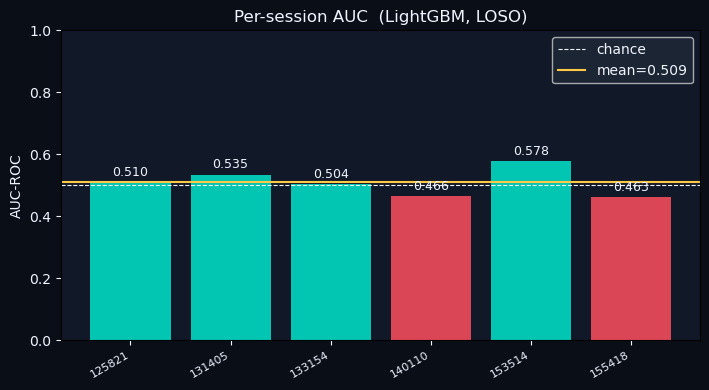

In [14]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(max(6, len(fold_results)*1.2), 4),
                        facecolor=DARK)
ax.set_facecolor(CARD)
sids   = [r['session'] for r in fold_results]
aucs   = [r['auc']     for r in fold_results]
colors = [TEAL if a >= 0.5 else CORAL for a in aucs]
bars   = ax.bar(sids, aucs, color=colors, alpha=0.85)
ax.axhline(0.5,      color=WHITE,  linestyle='--', linewidth=0.8, label='chance')
ax.axhline(mean_auc, color=GOLD,   linestyle='-',  linewidth=1.5,
           label=f'mean={mean_auc:.3f}')
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=9, color=WHITE)
ax.set_xticks(sids)
ax.set_xticklabels([r['stamp'] for r in fold_results],
                   rotation=30, ha='right', fontsize=8, color=WHITE)
ax.set_ylabel('AUC-ROC', color=WHITE)
ax.set_ylim(0, 1)
ax.tick_params(colors=WHITE)
ax.set_title('Per-session AUC  (LightGBM, LOSO)', color=WHITE)
ax.legend(facecolor=EDGE, labelcolor=WHITE)
plt.tight_layout()
plt.show()


In [15]:
# Train final model on ALL data
import pickle, os

final_model = lgb_fn(X_feat_all, y_win)
os.makedirs('models', exist_ok=True)
with open(f'models/lgb_s{SUBJECT}_gng2_loso.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print('Model saved.')


Model saved.


## 10 · ROC & Precision-Recall Curves

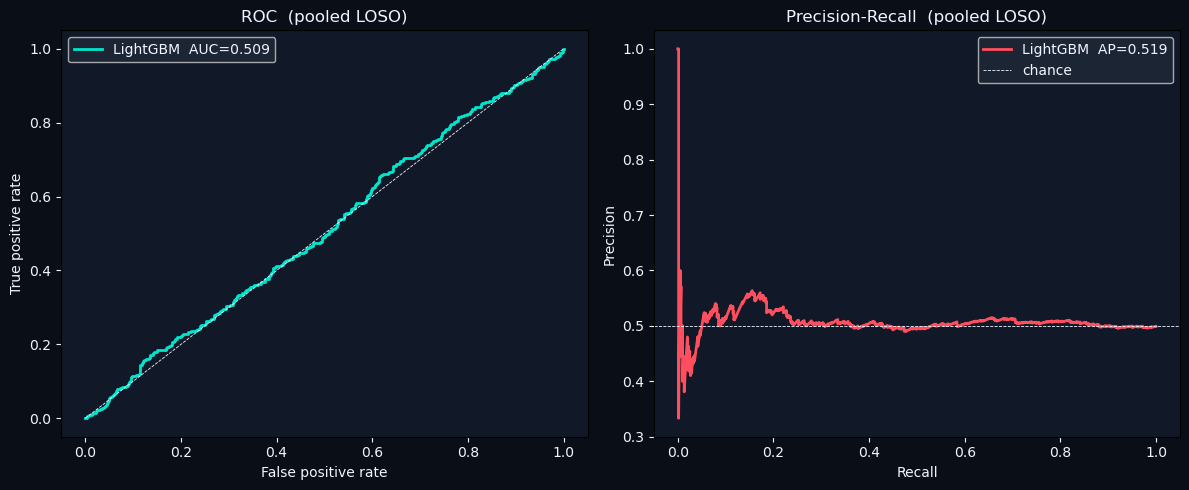

In [16]:
%matplotlib inline

fpr, tpr, _ = roc_curve(all_true, all_probs)
prec, rec, _ = precision_recall_curve(all_true, all_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=DARK)
for ax in axes:
    ax.set_facecolor(CARD)

axes[0].plot(fpr, tpr, color=TEAL, linewidth=2,
             label=f'LightGBM  AUC={mean_auc:.3f}')
axes[0].plot([0, 1], [0, 1], color=WHITE, linewidth=0.6, linestyle='--')
axes[0].set_xlabel('False positive rate', color=WHITE)
axes[0].set_ylabel('True positive rate',  color=WHITE)
axes[0].set_title('ROC  (pooled LOSO)', color=WHITE)
axes[0].legend(facecolor=EDGE, labelcolor=WHITE)
axes[0].tick_params(colors=WHITE)

axes[1].plot(rec, prec, color=CORAL, linewidth=2,
             label=f'LightGBM  AP={mean_ap:.3f}')
axes[1].axhline(all_true.mean(), color=WHITE, linewidth=0.6,
                linestyle='--', label='chance')
axes[1].set_xlabel('Recall',    color=WHITE)
axes[1].set_ylabel('Precision', color=WHITE)
axes[1].set_title('Precision-Recall  (pooled LOSO)', color=WHITE)
axes[1].legend(facecolor=EDGE, labelcolor=WHITE)
axes[1].tick_params(colors=WHITE)

plt.tight_layout()
plt.show()


## 11 · Feature Importance

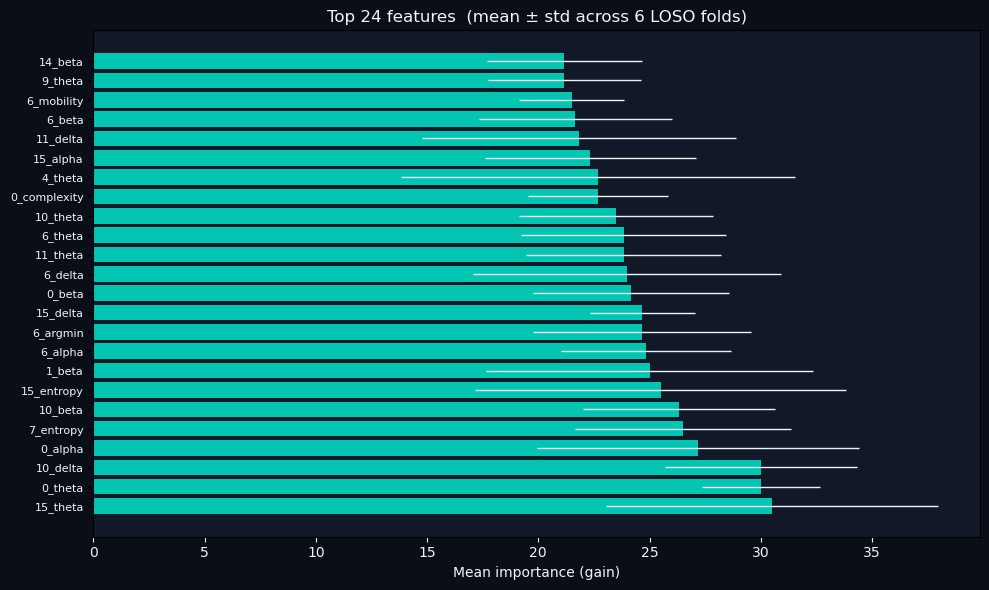

In [17]:
%matplotlib inline

TOP_N = 24
order    = np.argsort(mean_imp)[::-1][:TOP_N]
imp_top  = mean_imp[order]
std_top  = std_imp[order]
names    = [FEAT_NAMES[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 6), facecolor=DARK)
ax.set_facecolor(CARD)
y_pos = np.arange(TOP_N)
ax.barh(y_pos, imp_top, xerr=std_top, color=TEAL, alpha=0.85,
        error_kw=dict(ecolor=WHITE, lw=1))
ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=8, color=WHITE)
ax.tick_params(axis='x', colors=WHITE)
ax.set_xlabel('Mean importance (gain)', color=WHITE)
ax.set_title(f'Top {TOP_N} features  (mean \u00b1 std across {n_sessions} LOSO folds)',
             color=WHITE)
plt.tight_layout()
plt.show()


## 12 · Per-Session Metrics

In [18]:
print(f'\nLOSO Summary  \u2014  Subject {SUBJECT}  {DATE}')
print('=' * 52)
print(f'  Features : {len(FEAT_NAMES)}  ({N_CH} channels x 18)')
print(f'  Windows  : {N_WINS} x {WIN_S*1000:.0f} ms per epoch')
print(f'  Filter   : {HP}\u2013{LP} Hz')
print(f'  LOSO AUC : {mean_auc:.4f} \u00b1{res["std_auc"]:.4f}')
print(f'  LOSO AP  : {mean_ap:.4f}')
print()
print(f'  {"Session":<12} {"AUC":>8}  {"AP":>8}')
print('  ' + '-' * 30)
for r in fold_results:
    print(f'  {r["stamp"]:<12} {r["auc"]:>8.4f}  {r["ap"]:>8.4f}')



LOSO Summary  —  Subject Z  20260618
  Features : 288  (16 channels x 18)
  Windows  : 3 x 500 ms per epoch
  Filter   : 0.5–15.0 Hz
  LOSO AUC : 0.5093 ±0.0396
  LOSO AP  : 0.5190

  Session           AUC        AP
  ------------------------------
  125821         0.5104    0.5169
  131405         0.5347    0.5224
  133154         0.5036    0.5223
  140110         0.4662    0.4832
  153514         0.5780    0.5787
  155418         0.4631    0.4903


## 13 · Per-session AUC details

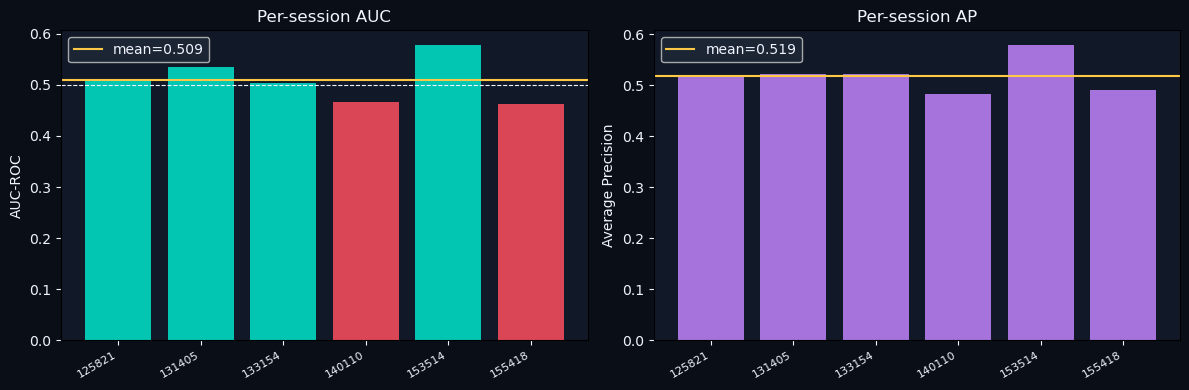

In [19]:
%matplotlib inline

sessions_l = [r['session'] for r in fold_results]
aucs_l     = [r['auc']     for r in fold_results]
aps_l      = [r['ap']      for r in fold_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=DARK)
for ax in axes:
    ax.set_facecolor(CARD)

colors_l = [TEAL if a >= 0.5 else CORAL for a in aucs_l]
axes[0].bar(sessions_l, aucs_l, color=colors_l, alpha=0.85)
axes[0].axhline(0.5,      color=WHITE, linestyle='--', linewidth=0.8)
axes[0].axhline(mean_auc, color=GOLD,  linestyle='-',  linewidth=1.5,
                label=f'mean={mean_auc:.3f}')
axes[0].set_xticks(sessions_l)
axes[0].set_xticklabels([r['stamp'] for r in fold_results],
                         rotation=30, ha='right', fontsize=8, color=WHITE)
axes[0].set_ylabel('AUC-ROC', color=WHITE)
axes[0].set_title('Per-session AUC', color=WHITE)
axes[0].tick_params(colors=WHITE)
axes[0].legend(facecolor=EDGE, labelcolor=WHITE)

axes[1].bar(sessions_l, aps_l, color=PURPLE, alpha=0.85)
axes[1].axhline(mean_ap, color=GOLD, linestyle='-', linewidth=1.5,
                label=f'mean={mean_ap:.3f}')
axes[1].set_xticks(sessions_l)
axes[1].set_xticklabels([r['stamp'] for r in fold_results],
                         rotation=30, ha='right', fontsize=8, color=WHITE)
axes[1].set_ylabel('Average Precision', color=WHITE)
axes[1].set_title('Per-session AP', color=WHITE)
axes[1].tick_params(colors=WHITE)
axes[1].legend(facecolor=EDGE, labelcolor=WHITE)

plt.tight_layout()
plt.show()


## 13 · ROC & Precision-Recall Curves

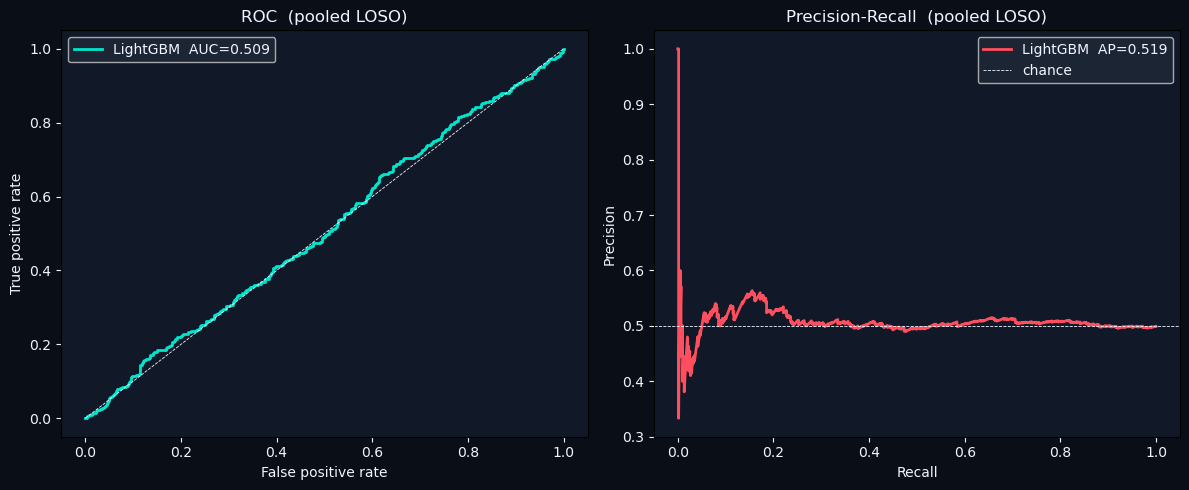

In [20]:
%matplotlib inline

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5), facecolor=DARK)
for ax in (ax_roc, ax_pr):
    ax.set_facecolor(CARD)

fpr_c, tpr_c, _ = roc_curve(all_true, all_probs)
ax_roc.plot(fpr_c, tpr_c, color=TEAL, linewidth=2,
            label=f'LightGBM  AUC={mean_auc:.3f}')
ax_roc.plot([0, 1], [0, 1], color=WHITE, linewidth=0.6, linestyle='--')
ax_roc.set_xlabel('False positive rate', color=WHITE)
ax_roc.set_ylabel('True positive rate',  color=WHITE)
ax_roc.set_title('ROC  (pooled LOSO)', color=WHITE)
ax_roc.legend(facecolor=EDGE, labelcolor=WHITE)
ax_roc.tick_params(colors=WHITE)

prec_c, rec_c, _ = precision_recall_curve(all_true, all_probs)
ax_pr.plot(rec_c, prec_c, color=CORAL, linewidth=2,
           label=f'LightGBM  AP={mean_ap:.3f}')
ax_pr.axhline(all_true.mean(), color=WHITE, linewidth=0.6,
              linestyle='--', label='chance')
ax_pr.set_xlabel('Recall',    color=WHITE)
ax_pr.set_ylabel('Precision', color=WHITE)
ax_pr.set_title('Precision-Recall  (pooled LOSO)', color=WHITE)
ax_pr.legend(facecolor=EDGE, labelcolor=WHITE)
ax_pr.tick_params(colors=WHITE)

plt.tight_layout()
plt.show()


## 14 · Feature Importance

Top features averaged and std-ranked across 10 LOTO folds.
Feature names encode channel and feature type: `ch{N}_{feature}`.

NameError: name 'mpatches' is not defined

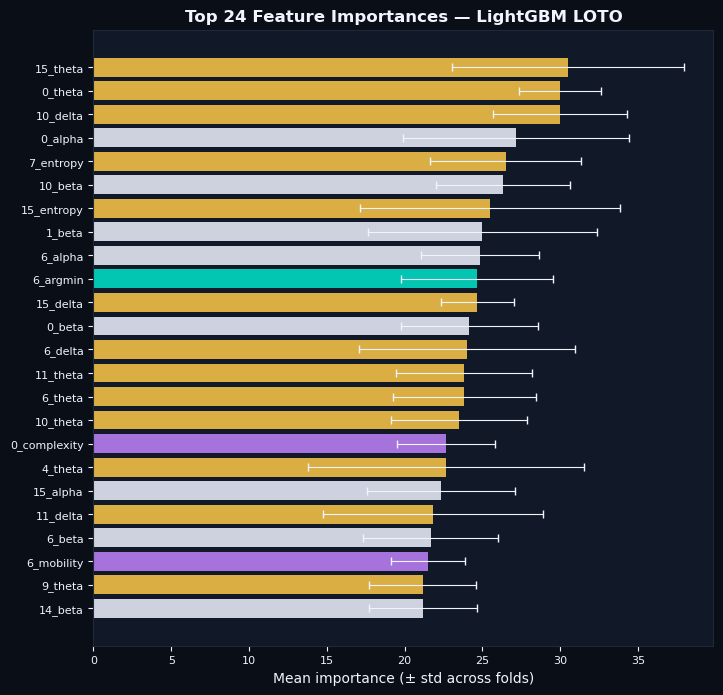

In [21]:
%matplotlib inline
TOP_N = 24

order = np.argsort(mean_imp)[::-1][:TOP_N]
imp_top = mean_imp[order]
std_top = std_imp[order]
names = [FEAT_NAMES[i] for i in order]

family_colors = {
    "mean": TEAL,
    "std": TEAL,
    "slope": TEAL,
    "min": TEAL,
    "argmin": TEAL,
    "rms": TEAL,
    "delta": GOLD,
    "theta": GOLD,
    "entropy": GOLD,
    "activity": PURPLE,
    "mobility": PURPLE,
    "complexity": PURPLE,
}
bar_colors = [family_colors.get(n.split("_", 1)[1], WHITE) for n in names]

fig, ax = plt.subplots(figsize=(8, 8), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.tick_params(colors=WHITE, labelsize=8)

y_pos = np.arange(TOP_N)
ax.barh(
    y_pos,
    imp_top[::-1],
    xerr=std_top[::-1],
    color=bar_colors[::-1],
    alpha=0.85,
    error_kw=dict(ecolor=WHITE, capsize=3, lw=0.8),
)

ax.set_yticks(y_pos)
ax.set_yticklabels(names[::-1], fontsize=8, color=WHITE)
ax.set_xlabel("Mean importance (± std across folds)", color=WHITE)
ax.set_title(
    f"Top {TOP_N} Feature Importances — LightGBM LOTO", color=WHITE, fontweight="bold"
)

legend_handles = [
    mpatches.Patch(color=TEAL, alpha=0.85, label="Temporal features"),
    mpatches.Patch(color=GOLD, alpha=0.85, label="Frequency features"),
    mpatches.Patch(color=PURPLE, alpha=0.85, label="Hjorth features"),
]
ax.legend(handles=legend_handles, facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

plt.tight_layout()
plt.savefig("report/lgb_importance.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → report/lgb_importance.png")

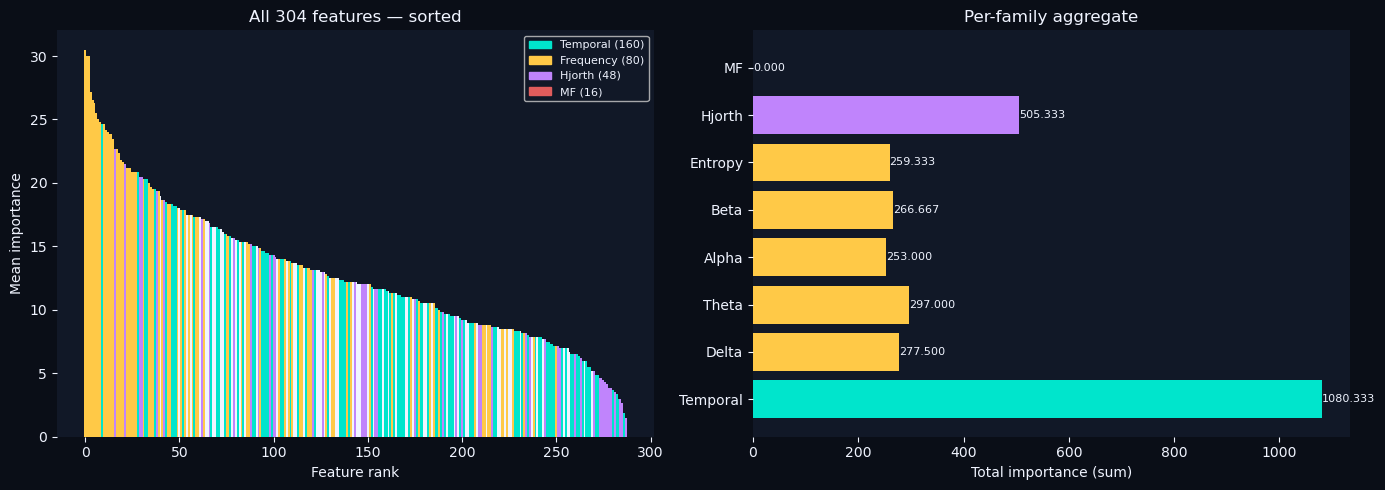

Features with importance < 0.001:
  Temporal  : 0/96 near-zero
  Delta     : 0/16 near-zero
  Theta     : 0/16 near-zero
  Alpha     : 0/16 near-zero
  Beta      : 0/16 near-zero
  Entropy   : 0/16 near-zero
  Hjorth    : 0/48 near-zero
  MF        : 0/0 near-zero


In [22]:
%matplotlib inline

# Full 304-feature importance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)

# --- Left: sorted bar of all features, coloured by family ---
all_order = np.argsort(mean_imp)[::-1]
family_map = {
    "mean": TEAL, "std": TEAL, "slope": TEAL, "min": TEAL,
    "argmin": TEAL, "rms": TEAL, "seg0": TEAL, "seg1": TEAL,
    "seg2": TEAL, "seg3": TEAL,
    "delta": GOLD, "theta": GOLD, "alpha": GOLD, "beta": GOLD, "entropy": GOLD,
    "activity": PURPLE, "mobility": PURPLE, "complexity": PURPLE,
    "mf": "#e05c5c",
}
bar_c = [family_map.get(FEAT_NAMES[i].split("_", 1)[1], WHITE) for i in all_order]

ax = axes[0]
ax.set_facecolor(CARD)
ax.bar(np.arange(len(mean_imp)), mean_imp[all_order], color=bar_c, width=1.0, linewidth=0)
ax.set_xlabel("Feature rank", color=WHITE)
ax.set_ylabel("Mean importance", color=WHITE)
ax.set_title("All 304 features — sorted", color=WHITE)
ax.tick_params(colors=WHITE)
for sp in ax.spines.values():
    sp.set_visible(False)

# legend
from matplotlib.patches import Patch
legend_items = [
    Patch(color=TEAL,     label=f"Temporal ({N_CH*10})"),
    Patch(color=GOLD,     label=f"Frequency ({N_CH*5})"),
    Patch(color=PURPLE,   label=f"Hjorth ({N_CH*3})"),
    Patch(color="#e05c5c",label=f"MF ({N_CH})"),
]
ax.legend(handles=legend_items, facecolor=CARD, labelcolor=WHITE, fontsize=8)

# --- Right: per-family aggregate importance ---
families = {
    "Temporal": [i for i, n in enumerate(FEAT_NAMES) if n.split("_",1)[1] in
                 ("mean","std","slope","min","argmin","rms","seg0","seg1","seg2","seg3")],
    "Delta":    [i for i, n in enumerate(FEAT_NAMES) if "delta"    in n],
    "Theta":    [i for i, n in enumerate(FEAT_NAMES) if "theta"    in n],
    "Alpha":    [i for i, n in enumerate(FEAT_NAMES) if "alpha"    in n],
    "Beta":     [i for i, n in enumerate(FEAT_NAMES) if "beta"     in n],
    "Entropy":  [i for i, n in enumerate(FEAT_NAMES) if "entropy"  in n],
    "Hjorth":   [i for i, n in enumerate(FEAT_NAMES) if n.split("_",1)[1] in
                 ("activity","mobility","complexity")],
    "MF":       [i for i, n in enumerate(FEAT_NAMES) if "mf"       in n],
}
fam_names = list(families.keys())
fam_totals = [mean_imp[idx].sum() for idx in families.values()]
fam_colors = [TEAL, GOLD, GOLD, GOLD, GOLD, GOLD, PURPLE, "#e05c5c"]

ax2 = axes[1]
ax2.set_facecolor(CARD)
bars = ax2.barh(fam_names, fam_totals, color=fam_colors)
ax2.set_xlabel("Total importance (sum)", color=WHITE)
ax2.set_title("Per-family aggregate", color=WHITE)
ax2.tick_params(colors=WHITE)
for sp in ax2.spines.values():
    sp.set_visible(False)
for bar, val in zip(bars, fam_totals):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", color=WHITE, fontsize=8)

fig.tight_layout()
plt.show()

# Print zero/near-zero count per family
print("Features with importance < 0.001:")
for name, idx in families.items():
    n_low = (mean_imp[idx] < 0.001).sum()
    print(f"  {name:10s}: {n_low}/{len(idx)} near-zero")


## 15 · Detection Latency Distribution

For every detected press event, how many milliseconds *before* the press did the model first cross the threshold?  A distribution peaking near −500 ms confirms anticipatory detection, not reactive detection.

In [23]:
%matplotlib inline

latencies_ms = []

for t in TEST_TRIALS:
    _, _, y_mom_t = raw_data[t]
    press_samps = np.where(y_mom_t > 0)[0]
    n_win_t = int((tid_all == t).sum())

    for ps in press_samps:
        win_k = ps - T_MAX
        if win_k < 1 or win_k >= n_win_t:
            continue
        gl_k = trial_offset[t] + win_k
        # Search backwards from press for first threshold crossing
        look_back = min(win_k, HORIZON)
        window = scores_s[gl_k - look_back : gl_k + 1]
        crossings = np.where(window >= thresh)[0]
        if len(crossings) == 0:
            continue  # missed event — skip
        # First crossing relative to press (negative = before)
        first_cross = crossings[0] - look_back  # ≤ 0
        latencies_ms.append(first_cross / FS_EFF * 1000)

latencies_ms = np.array(latencies_ms)
print(f"Detected events with latency data: {len(latencies_ms)}")
print(f"Median latency : {np.median(latencies_ms):.0f} ms")
print(f"Mean latency   : {np.mean(latencies_ms):.0f} ms")

fig, ax = plt.subplots(figsize=(9, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.tick_params(colors=WHITE)

bins = np.linspace(-HORIZON / FS_EFF * 1000, 100, 40)
ax.hist(latencies_ms, bins=bins, color=TEAL, alpha=0.85, edgecolor=DARK, lw=0.5)
ax.axvline(
    np.median(latencies_ms),
    color=CORAL,
    lw=2,
    ls="--",
    label=f"Median {np.median(latencies_ms):.0f} ms",
)
ax.axvline(0, color=WHITE, lw=1, ls="-", alpha=0.5, label="Press moment")

ax.set_xlabel("Detection latency (ms, negative = before press)", color=WHITE)
ax.set_ylabel("Count", color=WHITE)
ax.set_title(
    "Detection Latency Distribution  (anticipatory = negative)",
    color=WHITE,
    fontweight="bold",
)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

plt.tight_layout()
plt.savefig("report/lgb_latency.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → report/lgb_latency.png")

NameError: name 'TEST_TRIALS' is not defined

## 16 · Summary

In [23]:
e = evt
eg = res["evt_gated"]
print("=" * 60)
print(f"  LightGBM + Eng Features — Subject {SUBJECT}  LOTO CV")
print("=" * 60)
print(
    f"  Features       : {N_CH*10 + N_CH*5 + N_CH*3 + N_CH}  (temporal {N_CH*10} + freq {N_CH*5} + Hjorth {N_CH*3} + MF {N_CH})"
)
print(f"  Window (T_OPT) : {T_OPT/FS_EFF:.2f} s ({T_OPT} samples @ {FS_EFF} Hz)")
print(
    f"  Horizon        : {HORIZON/FS_EFF*1000:.0f} ms  Smooth: {SMOOTH_WIN/FS_EFF*1000:.0f} ms"
)
print(
    f"  Refractory     : {REFRACTORY/FS_EFF*1000:.0f} ms   Persist gate: {PERSIST_K} samp = {PERSIST_K/FS_EFF*1000:.0f} ms"
)
print(f"  Threshold      : {thresh:.4f}  (spec ≥ {MIN_SPEC:.0%}, CV-tuned)")
print()
print(f"  {'Metric':<20} {'No gate':>10}  {'+ gate':>10}")
print(f"  {'-'*42}")
print(f"  {'LOTO AUC':<20} {res['auc']:>10.4f}")
print(f"  {'LOTO AP':<20} {res['ap']:>10.4f}")
print(
    f"  {'Event sens.':<20} {e['event_sensitivity']:>10.3f}  {eg['event_sensitivity']:>10.3f}"
)
print(f"  {'FA / min':<20} {e['fa_per_minute']:>10.1f}  {eg['fa_per_minute']:>10.1f}")
print(
    f"  {'Mean latency (ms)':<20} {e.get('mean_latency_ms', 0):>10.1f}  {eg.get('mean_latency_ms', 0):>10.1f}"
)
print(
    f"  {'Events detected':<20} {e['n_detected']:>5}/{e['n_events']:<4}   {eg['n_detected']:>5}/{eg['n_events']:<4}"
)
print("=" * 60)
print()
print("Saved plots:")
for fname in [
    "lgb_timelines",
    "lgb_erp",
    "lgb_event_zoom",
    "lgb_per_fold",
    "lgb_roc_pr",
    "lgb_importance",
    "lgb_latency",
]:
    p = f"report/{fname}.png"
    exists = os.path.exists(p)

  LightGBM + Eng Features — Subject V  LOTO CV
  Features       : 323  (temporal 170 + freq 85 + Hjorth 51 + MF 17)
  Window (T_OPT) : 1.27 s (75 samples @ 59 Hz)
  Horizon        : 2000 ms  Smooth: 85 ms
  Refractory     : 1000 ms   Persist gate: 1 samp = 17 ms
  Threshold      : 0.5725  (spec ≥ 90%, CV-tuned)

  Metric                  No gate      + gate
  ------------------------------------------
  LOTO AUC                 0.4994
  LOTO AP                  0.3682
  Event sens.               0.719       0.719
  FA / min                   22.4        22.4
  Mean latency (ms)        1449.7      1449.7
  Events detected        217/302      217/302 

Saved plots:


In [24]:
tid_all

array([0, 0, 0, ..., 5, 5, 5], dtype=int32)

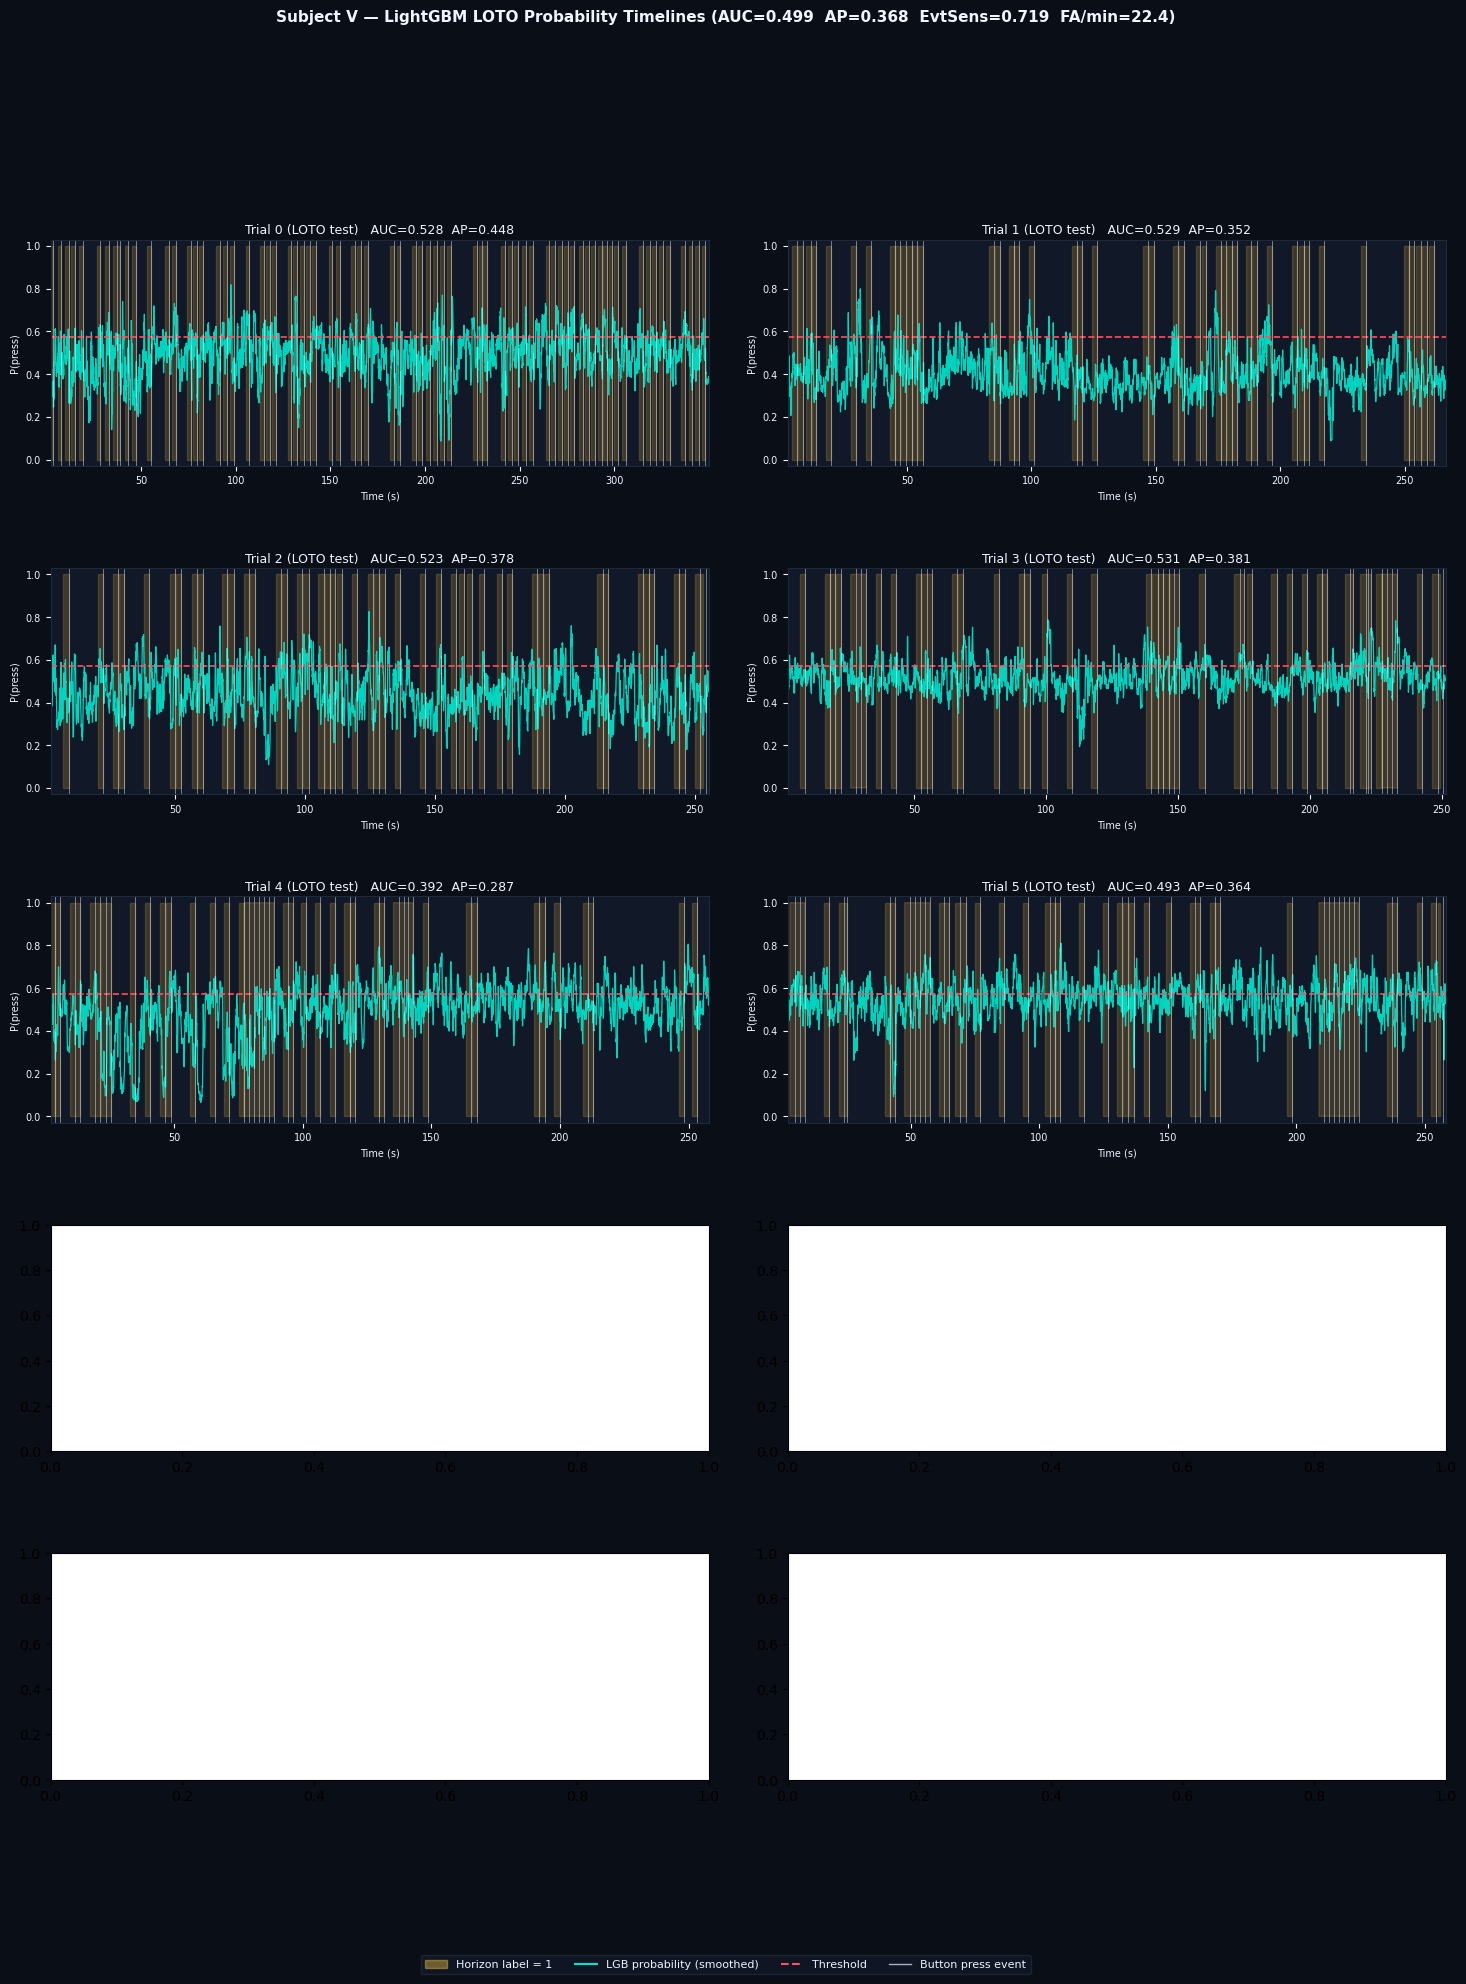

Saved → report/lgb_timelines.png


In [25]:
%matplotlib inline
os.makedirs("report", exist_ok=True)

fold_by_trial = {r["trial"]: r for r in fold_results}

fig, axes = plt.subplots(
    5, 2, figsize=(18, 20), facecolor=DARK, gridspec_kw=dict(hspace=0.45, wspace=0.12)
)

for idx, t in enumerate(ALL_TRIALS):
    ax = axes[idx // 2, idx % 2]
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    ax.tick_params(colors=WHITE, labelsize=7)

    m = tid_all == t
    sc = scores_s[m]
    yl = y_all[m].astype(bool)
    n = m.sum()

    t_sec = (T_MAX + np.arange(n)) / FS_EFF

    ax.fill_between(
        t_sec, 0, 1, where=yl, color=GOLD, alpha=0.18, step="post", label="Label=1"
    )
    ax.plot(t_sec, sc, color=TEAL, lw=0.9, label="P(press)", alpha=0.92)
    ax.axhline(thresh, color=CORAL, lw=1.2, ls="--", label=f"Threshold {thresh:.3f}")

    _, _, y_mom_t = raw_data[t]
    press_samps = np.where(y_mom_t > 0)[0]
    for ps in press_samps:
        ps_time = ps / FS_EFF
        if t_sec[0] <= ps_time <= t_sec[-1]:
            ax.axvline(ps_time, color=WHITE, lw=0.6, alpha=0.55)

    if t in fold_by_trial:
        fold_auc = fold_by_trial[t]["auc"]
        fold_ap = fold_by_trial[t]["ap"]
        title_label = f"Trial {t} (LOTO test)   AUC={fold_auc:.3f}  AP={fold_ap:.3f}"
    else:
        title_label = f"Trial {t} (calibration — train only)"

    ax.set_title(title_label, color=WHITE, fontsize=9, pad=4)
    ax.set_xlim(t_sec[0], t_sec[-1])
    ax.set_ylim(-0.03, 1.03)
    ax.set_xlabel("Time (s)", color=WHITE, fontsize=7)
    ax.set_ylabel("P(press)", color=WHITE, fontsize=7)

handles = [
    mpatches.Patch(color=GOLD, alpha=0.4, label="Horizon label = 1"),
    plt.Line2D([0], [0], color=TEAL, lw=1.5, label="LGB probability (smoothed)"),
    plt.Line2D([0], [0], color=CORAL, lw=1.5, ls="--", label="Threshold"),
    plt.Line2D([0], [0], color=WHITE, lw=1.0, alpha=0.7, label="Button press event"),
]
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    facecolor=CARD,
    labelcolor=WHITE,
    edgecolor=EDGE,
    fontsize=8,
    bbox_to_anchor=(0.5, 0.01),
)

fig.suptitle(
    f"Subject {SUBJECT} — LightGBM LOTO Probability Timelines "
    f'(AUC={res["auc"]:.3f}  AP={res["ap"]:.3f}  '
    f'EvtSens={evt["event_sensitivity"]:.3f}  '
    f'FA/min={evt["fa_per_minute"]:.1f})',
    color=WHITE,
    fontsize=11,
    y=0.995,
    fontweight="bold",
)

plt.savefig("report/lgb_timelines.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → report/lgb_timelines.png")

In [26]:
LAT = []
for idx, t in enumerate(ALL_TRIALS):
    
    m = tid_all == t
    sc = scores_s[m]
    yl = y_all[m].astype(bool)
    n = m.sum()

    button_press_onset = np.concatenate(([0], np.where(yl)[0]))
    button_press_offset = np.roll(button_press_onset, -1)
    detection = np.where(sc >= thresh)[0]

    for previous, current in zip(button_press_onset, button_press_offset):
        if current == 0:
            continue
        else:
            for det in detection:
                if previous <= det <= current - HORIZON:
                    LAT.append( (det - HORIZON)) # TIME OF FA

LAT = np.hstack(LAT)

In [27]:
LAT = []
for t in ALL_TRIALS:
    m = tid_all == t
    sc = scores_s[m]
    press_idx = np.where(y_mom[m] > 0)[0]   # actual press onsets only
    detections = np.where(sc >= thresh)[0]

    if len(press_idx) == 0:
        continue
    last_press = press_idx[-1]

    for det in detections:
        # True positive: within HORIZON before a press
        is_tp = any((p - HORIZON) <= det <= p for p in press_idx)
        if not is_tp:
            future = press_idx[press_idx > det]
            # Exclude FAs whose only future press is the last one in the trial
            # (last inter-press gap is often artificially long)
            if len(future) > 0 and future[0] != last_press:
                LAT.append((future[0] - det) / FS_EFF * 1000)  # ms to next press

LAT = np.array(LAT)

(array([923., 787., 792., 579., 489., 388., 346., 488., 540., 434., 465.,
        321., 198., 205., 246., 329., 260., 265., 319., 278., 242., 204.,
        225., 146.,  95.,  50.,  83., 102.,  79., 100.,  66., 125., 138.,
         80., 106.,  86.,  52.,  38.,  42.,  39.,  67.,  54.,  22.,  55.,
         75.,  32.,  31.,  42.,  22.,  33.,  27.,  12.,  13.,  16.,  24.,
         37.,  33.,  32.,  31.,  20.,  10.,  43.,  43.,  35.,  45.,  37.,
          4.,   0.,  15.,  23.,  10.,   5.,   0.,   0.,   0.,   0.,  13.,
         22.,  15.,   0.,  11.,  10.,   0.,   0.,   0.,   3.,  18.,  19.,
         19.,  19.,  19.,  15.,   0.,  11.,   9.,   0.,   0.,   0.,  15.,
         19.]),
 array([ 2016.94915254,  2336.44067797,  2655.93220339,  2975.42372881,
         3294.91525424,  3614.40677966,  3933.89830508,  4253.38983051,
         4572.88135593,  4892.37288136,  5211.86440678,  5531.3559322 ,
         5850.84745763,  6170.33898305,  6489.83050847,  6809.3220339 ,
         7128.81355932,  7448.

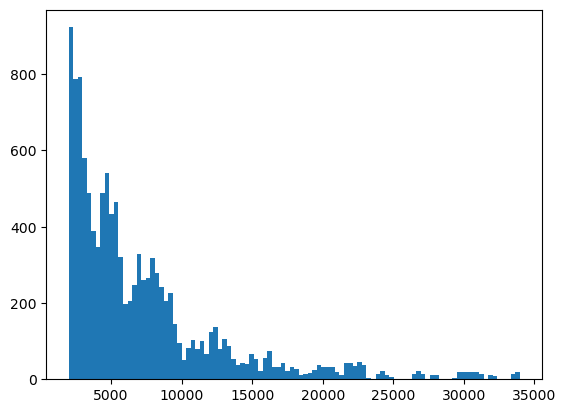

In [28]:
plt.hist(LAT, 100)